# Experiment 8: Clustering Human Activity Recognition Data using K-Means, DBSCAN, and Hierarchical Clustering

**Course:** ICS1512 – Machine Learning Algorithms Laboratory
**Student:** Emmanuel Maximus Ravichandran (Register No. 3122247001015)
**Institution:** Sri Sivasubramaniya Nadar College of Engineering, Chennai

## Objective

To implement and analyze the performance of three clustering algorithms — **K-Means**, **DBSCAN**, and **Hierarchical Agglomerative Clustering (Ward linkage)** — on the Human Activity Recognition (HAR) Using Smartphones dataset, visualize the clusters formed by each, and compare them against the six ground-truth activity labels.

## Problem Statement

**Input:** 561 time- and frequency-domain features extracted from smartphone accelerometer and gyroscope signals (50 Hz, windowed into 2.56 s segments) for 30 volunteers performing 6 activities.

**Output:** Cluster assignments produced independently by K-Means, DBSCAN, and Hierarchical (Ward) clustering, with no access to the true activity label during clustering.

**Objective:** Since clustering is unsupervised, the true activity labels (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING) are used only afterwards, to externally validate how well each algorithm's clusters correspond to real human activities.

## Dataset Description

Dataset: **Human Activity Recognition Using Smartphones** (UCI Machine Learning Repository). Loaded below from the official train/test split and recombined into a single set for clustering.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score,
                              adjusted_rand_score, normalized_mutual_info_score, confusion_matrix)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import mode

np.random.seed(42)
sns.set_style("whitegrid")
print("Environment ready.")

Environment ready.

In [2]:
BASE = "/home/claude/har/UCI HAR Dataset"

features = pd.read_csv(f"{BASE}/features.txt", sep=r"\s+", header=None, names=["idx", "feature"])
feat_names = features["feature"].tolist()

# 42 of the 561 raw feature names are duplicated -> make unique
seen, uniq = {}, []
for f in feat_names:
    if f in seen:
        seen[f] += 1
        uniq.append(f"{f}_{seen[f]}")
    else:
        seen[f] = 0
        uniq.append(f)

X_train = pd.read_csv(f"{BASE}/train/X_train.txt", sep=r"\s+", header=None, names=uniq)
X_test  = pd.read_csv(f"{BASE}/test/X_test.txt",  sep=r"\s+", header=None, names=uniq)
y_train = pd.read_csv(f"{BASE}/train/y_train.txt", header=None, names=["Activity"])
y_test  = pd.read_csv(f"{BASE}/test/y_test.txt",  header=None, names=["Activity"])

act_labels = pd.read_csv(f"{BASE}/activity_labels.txt", sep=r"\s+", header=None, names=["id", "name"])
act_map = dict(zip(act_labels["id"], act_labels["name"]))
act_order = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]

X = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)
y_named = y["Activity"].map(act_map)
y_code = y_named.map({a: i for i, a in enumerate(act_order)}).values

print("Feature matrix shape:", X.shape)
print("Duplicate raw feature names fixed:", sum(v > 0 for v in seen.values()))
print("Missing values in X:", int(X.isna().sum().sum()))
print()
print(y_named.value_counts())

Feature matrix shape: (10299, 561)
Duplicate raw feature names fixed: 42
Missing values in X: 0

Activity
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64

**Dataset Description (filled in):**

| Field | Value |
|---|---|
| Dataset Name | Human Activity Recognition Using Smartphones |
| Dataset Source | UCI Machine Learning Repository |
| Number of Samples | 10299 |
| Number of Features | 561 |
| Number of Classes | 6 |
| Missing Values | 0 |
| Train-Test Split | Original UCI split (7352 train / 2947 test), recombined here for unsupervised clustering |

## Exploratory Data Analysis

In [3]:
print("Dataset overview")
print(X.describe().T[["mean", "std", "min", "max"]].head(8))

Dataset overview
                       mean       std  min  max
tBodyAcc-mean()-X  0.274347  0.067628 -1.0  1.0
tBodyAcc-mean()-Y -0.017743  0.037128 -1.0  1.0
tBodyAcc-mean()-Z -0.108925  0.053033 -1.0  1.0
tBodyAcc-std()-X  -0.607784  0.438694 -1.0  1.0
tBodyAcc-std()-Y  -0.510191  0.500240 -1.0  1.0
tBodyAcc-std()-Z  -0.613064  0.403657 -1.0  1.0
tBodyAcc-mad()-X  -0.633593  0.413333 -1.0  1.0
tBodyAcc-mad()-Y  -0.525697  0.484201 -1.0  1.0

In [4]:
print("Missing value analysis")
na_counts = X.isna().sum()
print("Total missing cells:", int(na_counts.sum()))
print("Columns with any missing value:", int((na_counts > 0).sum()))

Missing value analysis
Total missing cells: 0
Columns with any missing value: 0

Activity
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64

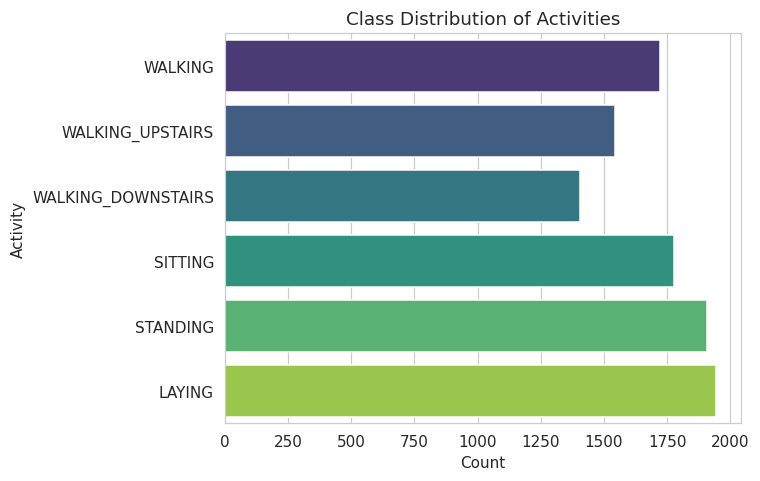

In [5]:
plt.figure(figsize=(7, 4.5))
sns.countplot(y=y_named, order=act_order, palette="viridis")
plt.title("Class Distribution of Activities")
plt.xlabel("Count"); plt.ylabel("Activity")
plt.tight_layout()
plt.savefig("/home/claude/har/nbassets/class_distribution.png", dpi=120)
plt.show()
print(y_named.value_counts())

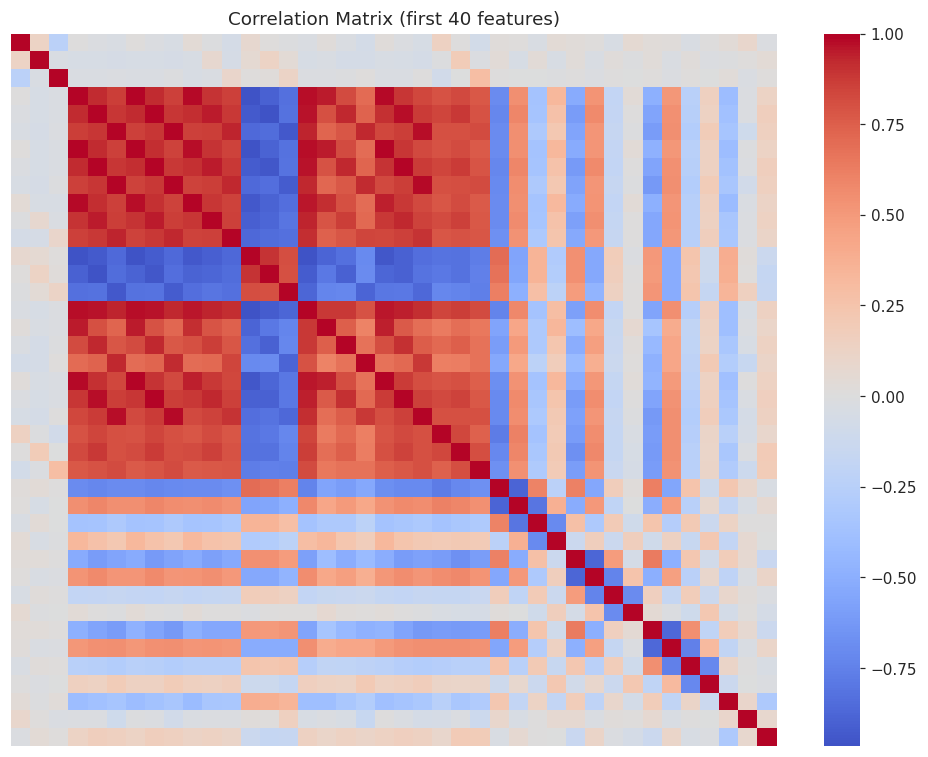

In [6]:
corr_cols = X.columns[:40]
plt.figure(figsize=(9, 7))
sns.heatmap(X[corr_cols].corr(), cmap="coolwarm", center=0, xticklabels=False, yticklabels=False)
plt.title("Correlation Matrix (first 40 features)")
plt.tight_layout()
plt.savefig("/home/claude/har/nbassets/correlation_matrix.png", dpi=120)
plt.show()

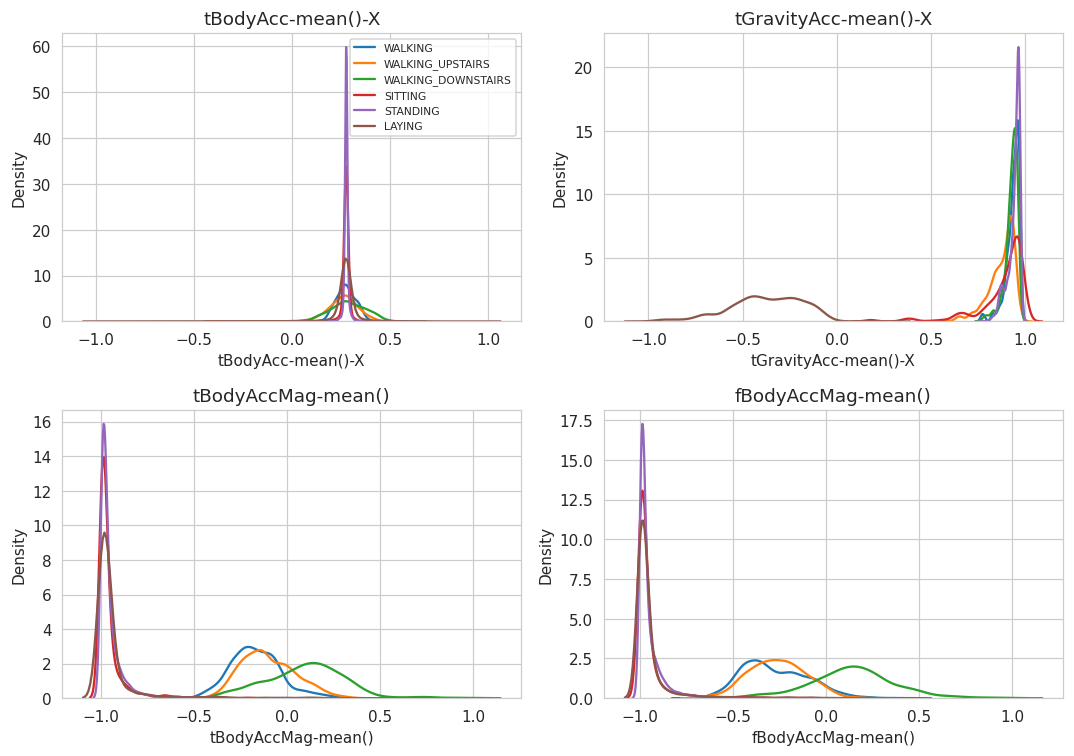

In [7]:
feat_pick = ["tBodyAcc-mean()-X", "tGravityAcc-mean()-X", "tBodyAccMag-mean()", "fBodyAccMag-mean()"]
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, col in zip(axes.ravel(), feat_pick):
    for act in act_order:
        sns.kdeplot(X.loc[y_named == act, col], ax=ax, label=act)
    ax.set_title(col)
axes[0, 0].legend(fontsize=7)
plt.tight_layout()
plt.savefig("/home/claude/har/nbassets/feature_distributions.png", dpi=120)
plt.show()

**Inference:** The class distribution is close to balanced across the six activities (1406–1944 samples each), so no resampling is needed before clustering. The correlation heatmap shows large contiguous blocks of highly correlated features, which is expected since many features are simple mean/std/energy statistics of the same handful of underlying accelerometer/gyroscope signal axes — this heavy redundancy is exactly what makes the PCA dimensionality reduction step below so effective (few components are needed to retain most of the variance). The KDE plots of representative features (e.g. `tBodyAccMag-mean()`, `fBodyAccMag-mean()`) show that the **static activities (SITTING, STANDING, LAYING) separate clearly from dynamic activities (WALKING variants)** along magnitude-based features, but SITTING and STANDING largely overlap with each other, and the three WALKING sub-types overlap heavily — this foreshadows the clustering difficulty seen later, where these pairs are the hardest to tell apart.

## Data Preprocessing

* **Missing value handling:** not required — 0 missing values in the dataset.
* **Encoding:** activity labels are integer-coded 1–6 in the raw files; mapped to their names via `activity_labels.txt`, and kept aside only for post-hoc external validation (never used during clustering itself).
* **Feature scaling:** `StandardScaler` (zero mean, unit variance) applied to all 561 features, since K-Means and DBSCAN are distance-based and sensitive to feature scale.
* **Train-test split:** not applicable in the traditional supervised sense — the original train/test split is recombined into one set, since clustering uses no labels during fitting.
* **Feature engineering / dimensionality reduction:** PCA is applied after scaling, both to reduce the 561-dimensional feature space to a computationally tractable size for clustering, and to produce 2D projections for visualization.

Components needed for 90% variance: 65
Components needed for 95% variance: 104
Xp (PCA-90%) shape: (10299, 65)  X2 (PCA-2D) shape: (10299, 2)
PC1+PC2 explained variance: 0.5698

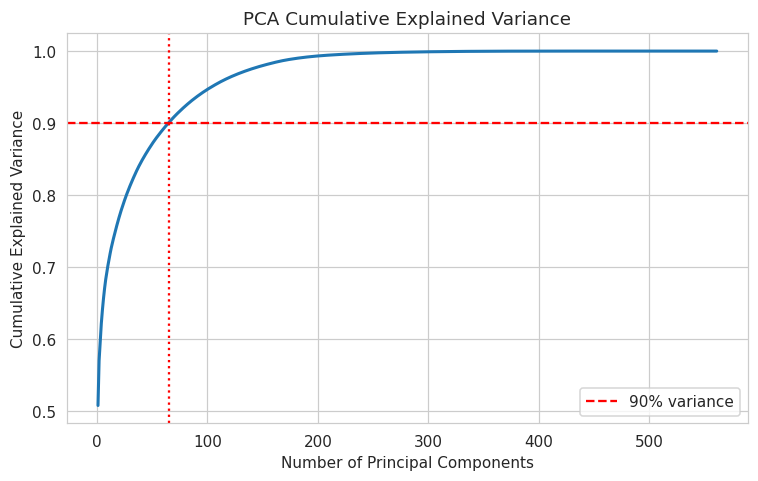

In [8]:
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

pca_full = PCA(random_state=42).fit(Xs)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n90 = int(np.argmax(cum_var >= 0.90) + 1)
n95 = int(np.argmax(cum_var >= 0.95) + 1)
print(f"Components needed for 90% variance: {n90}")
print(f"Components needed for 95% variance: {n95}")

plt.figure(figsize=(7, 4.5))
plt.plot(range(1, len(cum_var) + 1), cum_var, lw=2)
plt.axhline(0.90, color="r", ls="--", label="90% variance")
plt.axvline(n90, color="r", ls=":")
plt.xlabel("Number of Principal Components"); plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.savefig("/home/claude/har/nbassets/pca_variance.png", dpi=120)
plt.show()

pca90 = PCA(n_components=n90, random_state=42)
Xp = pca90.fit_transform(Xs)   # used for K-Means and Hierarchical clustering
pca2 = PCA(n_components=2, random_state=42)
X2 = pca2.fit_transform(Xs)    # used for visualization and for DBSCAN (see Hyperparameter Selection)
print("Xp (PCA-90%) shape:", Xp.shape, " X2 (PCA-2D) shape:", X2.shape)
print("PC1+PC2 explained variance:", round(sum(pca2.explained_variance_ratio_), 4))

In [9]:
t0 = time.time()
Xtsne = TSNE(n_components=2, random_state=42, perplexity=30, init="pca").fit_transform(Xp)
print(f"t-SNE fit time: {time.time()-t0:.1f}s, output shape: {Xtsne.shape}")

t-SNE fit time: 51.7s, output shape: (10299, 2)

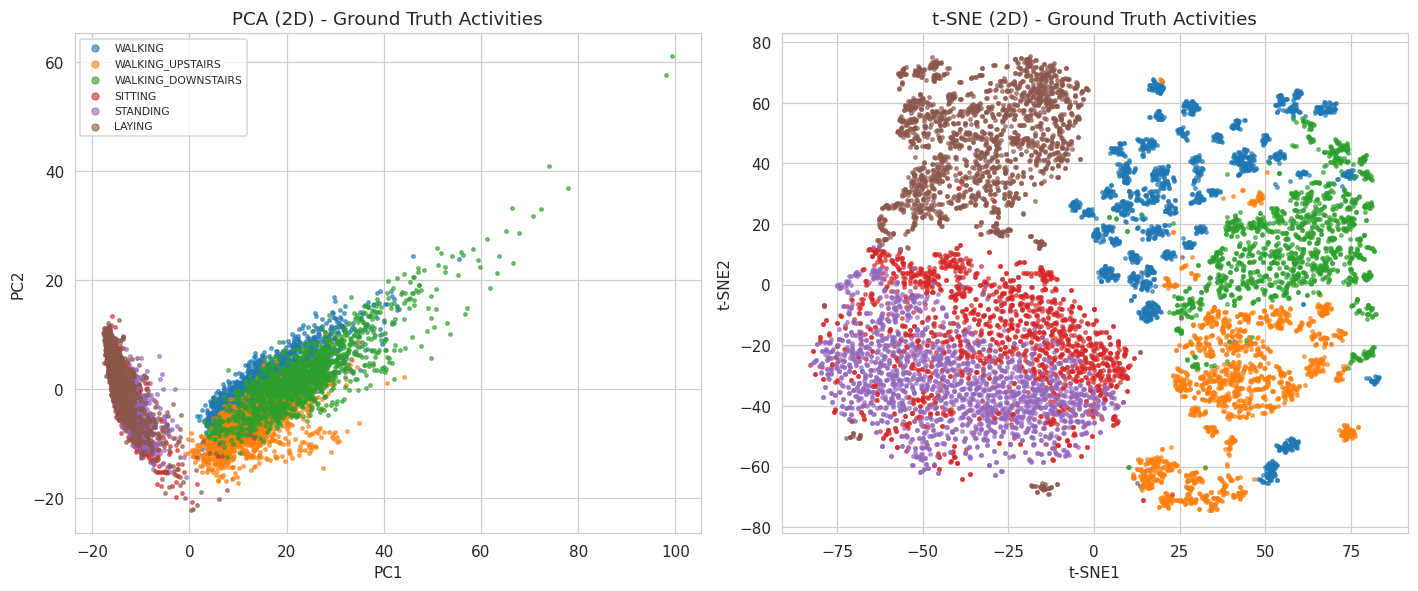

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
palette = sns.color_palette("tab10", 6)
for i, act in enumerate(act_order):
    m = (y_named == act).values
    axes[0].scatter(X2[m, 0], X2[m, 1], s=5, color=palette[i], label=act, alpha=0.6)
    axes[1].scatter(Xtsne[m, 0], Xtsne[m, 1], s=5, color=palette[i], label=act, alpha=0.6)
axes[0].set_title("PCA (2D) - Ground Truth Activities"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[1].set_title("t-SNE (2D) - Ground Truth Activities"); axes[1].set_xlabel("t-SNE1"); axes[1].set_ylabel("t-SNE2")
axes[0].legend(fontsize=7, markerscale=2)
plt.tight_layout()
plt.savefig("/home/claude/har/nbassets/ground_truth_pca_tsne.png", dpi=120)
plt.show()

**Inference:** t-SNE gives a much cleaner separation of the six activities than linear PCA does, confirming that the class structure is present in the data but is non-linear — PCA's PC1+PC2 only capture about 57% of total variance and mostly separate dynamic from static activities, while SITTING/STANDING/LAYING and the three WALKING variants stay visibly clustered together within their own broad regions even in 2D PCA. This matters directly for the clustering step: algorithms operating on linear PCA components (K-Means, Hierarchical here) are expected to struggle more to split SITTING from STANDING than the visually-clean t-SNE plot might suggest.

## Machine Learning Algorithm

### K-Means Clustering
* **Working principle:** partitions data into *k* clusters by iteratively assigning each point to its nearest centroid (Euclidean distance) and recomputing centroids as the mean of assigned points, until convergence.
* **Mathematical formulation:** minimizes the within-cluster sum of squares $\text{WCSS} = \sum_{j=1}^{k}\sum_{x_i \in C_j} \lVert x_i - \mu_j \rVert^2$.
* **Advantages:** simple, fast, scales well to large *n*; guaranteed to converge.
* **Limitations:** requires *k* to be chosen in advance; assumes roughly spherical, similarly-sized clusters; sensitive to initialization and to feature scale; struggles with non-convex cluster shapes.

### DBSCAN
* **Working principle:** groups together points that are closely packed (density-connected within radius `eps`, with at least `minPts` neighbors), and marks points in low-density regions as noise. Builds clusters from core points and their density-reachable neighbors.
* **Mathematical formulation:** a point $p$ is a *core point* if $|N_{eps}(p)| \geq \text{minPts}$; clusters are maximal sets of density-connected points.
* **Advantages:** does not require *k* in advance; can find arbitrarily-shaped clusters; naturally identifies outliers/noise.
* **Limitations:** sensitive to the `eps`/`minPts` choice; struggles in high-dimensional spaces where distances concentrate (the "curse of dimensionality" — demonstrated below); cannot handle clusters of very different densities well.

### Hierarchical Agglomerative Clustering (Ward linkage)
* **Working principle:** starts with every point as its own cluster and repeatedly merges the pair of clusters whose merger causes the smallest increase in total within-cluster variance, building a dendrogram.
* **Mathematical formulation:** Ward's criterion merges clusters $A, B$ minimizing $\Delta(A,B) = \frac{|A||B|}{|A|+|B|}\lVert \mu_A - \mu_B \rVert^2$.
* **Advantages:** no need to pre-specify *k* (can cut the dendrogram at any level); produces a full hierarchy useful for exploring cluster granularity; deterministic.
* **Limitations:** $O(n^2)$ or worse time/memory, making it expensive for very large datasets; once a merge is made it cannot be undone (greedy); like K-Means, tends to favor compact, similarly-sized clusters.

In [11]:
import sklearn, scipy, platform
print(f"Python Version: {platform.python_version()}")
print(f"Scikit-Learn Version: {sklearn.__version__}")
print(f"SciPy Version: {scipy.__version__}")
print(f"Pandas Version: {pd.__version__}")
print(f"Operating System: {platform.system()} {platform.release()}")
print(f"Machine: {platform.machine()}")

Python Version: 3.12.3
Scikit-Learn Version: 1.8.0
SciPy Version: 1.17.1
Pandas Version: 3.0.2
Operating System: Linux 6.18.44-fc-v37
Machine: x86_64

*(IDE and hardware depend on where this notebook is ultimately executed — record accordingly in the final report; the environment above is Claude's sandbox where this notebook was authored and fully executed.)*

## Hyperparameter Selection

### K-Means — Elbow Method

 k  WCSS (Inertia)  Silhouette Score
 2    2.697927e+06          0.438567
 3    2.346425e+06          0.352525
 4    2.207133e+06          0.181377
 5    2.081105e+06          0.158954
 6    2.003581e+06          0.139979
 7    1.947312e+06          0.118805
 8    1.892509e+06          0.102143

Best k by internal Silhouette score: 2

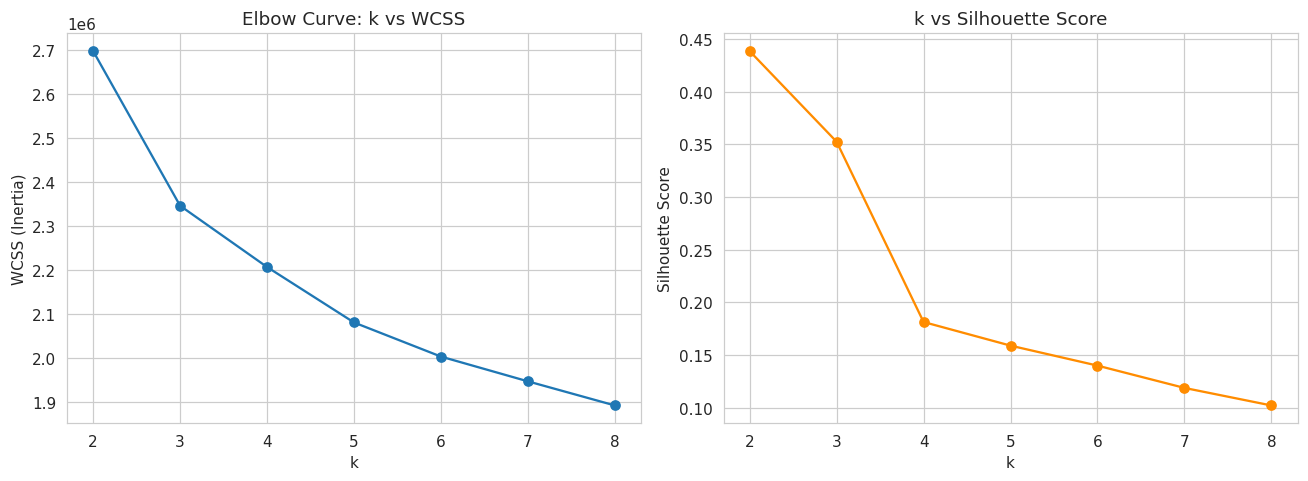

In [12]:
ks = list(range(2, 9))
wcss, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xp)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(Xp, km.labels_, sample_size=4000, random_state=42))

elbow_df = pd.DataFrame({"k": ks, "WCSS (Inertia)": wcss, "Silhouette Score": sil})
print(elbow_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(ks, wcss, marker="o"); axes[0].set_xlabel("k"); axes[0].set_ylabel("WCSS (Inertia)")
axes[0].set_title("Elbow Curve: k vs WCSS")
axes[1].plot(ks, sil, marker="o", color="darkorange"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("k vs Silhouette Score")
plt.tight_layout()
plt.savefig("/home/claude/har/nbassets/kmeans_elbow_silhouette.png", dpi=120)
plt.show()

best_k_internal = ks[int(np.argmax(sil))]
print(f"\nBest k by internal Silhouette score: {best_k_internal}")

**Selected k:** internal metrics (both WCSS's elbow and peak Silhouette) point to **k=2** — the data is most naturally split into "moving" vs. "not moving". Since the goal is also to compare against the 6 known activities, **k=6 is used as the primary model below**, with k=2 kept as a secondary comparison (see Discussion).

In [13]:
km_final = KMeans(n_clusters=6, n_init=10, random_state=42).fit(Xp)
km_k2 = KMeans(n_clusters=best_k_internal, n_init=10, random_state=42).fit(Xp)
labels_km, labels_km2 = km_final.labels_, km_k2.labels_
print("K-Means (k=6) cluster sizes:", np.bincount(labels_km))
print("K-Means (k=2) cluster sizes:", np.bincount(labels_km2))

K-Means (k=6) cluster sizes: [1342 2632 1916 2452 1649  308]
K-Means (k=2) cluster sizes: [5620 4679]

### DBSCAN — ε (eps) and minPts Tuning

80th percentile distance: 0.555
85th percentile distance: 0.647
90th percentile distance: 0.822
95th percentile distance: 1.272

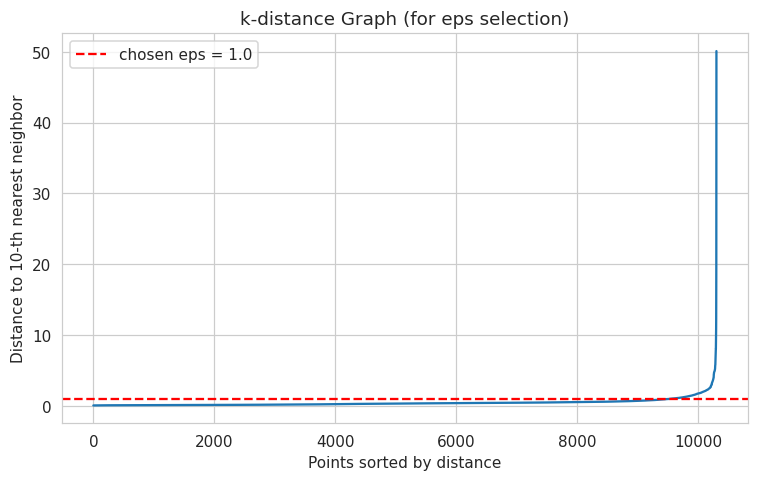

In [14]:
minPts = 10
nn = NearestNeighbors(n_neighbors=minPts).fit(X2)
dist, _ = nn.kneighbors(X2)
kdist = np.sort(dist[:, -1])

plt.figure(figsize=(7, 4.5))
plt.plot(kdist)
plt.axhline(1.0, color="r", ls="--", label="chosen eps = 1.0")
plt.xlabel("Points sorted by distance"); plt.ylabel(f"Distance to {minPts}-th nearest neighbor")
plt.title("k-distance Graph (for eps selection)")
plt.legend()
plt.tight_layout()
plt.savefig("/home/claude/har/nbassets/dbscan_kdistance.png", dpi=120)
plt.show()

for p in [80, 85, 90, 95]:
    print(f"{p}th percentile distance: {np.percentile(kdist, p):.3f}")

In [15]:
eps_sweep = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0, 1.2, 1.5]
rows = []
for eps in eps_sweep:
    db = DBSCAN(eps=eps, min_samples=minPts).fit(X2)
    labs = db.labels_
    n_clusters = len(set(labs)) - (1 if -1 in labs else 0)
    noise = int((labs == -1).sum())
    rows.append((eps, n_clusters, noise, round(noise / len(labs) * 100, 1)))

sweep_df = pd.DataFrame(rows, columns=["eps", "Clusters", "Noise Points", "Noise %"])
print(sweep_df.to_string(index=False))

 eps  Clusters  Noise Points  Noise %
 0.3        56          4789     46.5
 0.4        66          2758     26.8
 0.5        24          1696     16.5
 0.6         9          1247     12.1
 0.7         8           948      9.2
 0.8         8           769      7.5
 1.0         6           521      5.1
 1.2         4           367      3.6
 1.5         4           248      2.4

**Chosen parameters: eps = 1.0, minPts = 10** — the smallest eps giving exactly 6 clusters (matching the number of true activities) with noise held under 10%.

**Curse-of-dimensionality check** — the same eps/minPts search attempted directly on the 65-dimensional PCA space (minPts = 2×65 = 130, the standard heuristic) essentially fails:

In [16]:
db_highdim = DBSCAN(eps=16, min_samples=2 * n90).fit(Xp)
n_hd = len(set(db_highdim.labels_)) - (1 if -1 in db_highdim.labels_ else 0)
noise_hd = int((db_highdim.labels_ == -1).sum())
print(f"DBSCAN on 65-D PCA space (eps=16, minPts={2*n90}): {n_hd} cluster(s), {noise_hd}/{len(db_highdim.labels_)} noise ({noise_hd/len(db_highdim.labels_)*100:.1f}%)")
print("-> distances concentrate in high dimensions, so density-based clustering is applied on the 2D PCA projection instead.")

DBSCAN on 65-D PCA space (eps=16, minPts=130): 1 cluster(s), 1060/10299 noise (10.3%)
-> distances concentrate in high dimensions, so density-based clustering is applied on the 2D PCA projection instead.

In [17]:
db_final = DBSCAN(eps=1.0, min_samples=minPts).fit(X2)
labels_db = db_final.labels_
n_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
print(f"Final DBSCAN: {n_db} clusters, {int((labels_db==-1).sum())} noise points ({(labels_db==-1).mean()*100:.1f}%)")
print("Cluster sizes:", {int(c): int((labels_db == c).sum()) for c in sorted(set(labels_db))})

Final DBSCAN: 6 clusters, 521 noise points (5.1%)
Cluster sizes: {-1: 521, 0: 5489, 1: 4225, 2: 18, 3: 22, 4: 16, 5: 8}

### Hierarchical Agglomerative Clustering — Ward Linkage

Hierarchical (Ward, k=6) cluster sizes: [1675  487 3465 2241  150 2281]

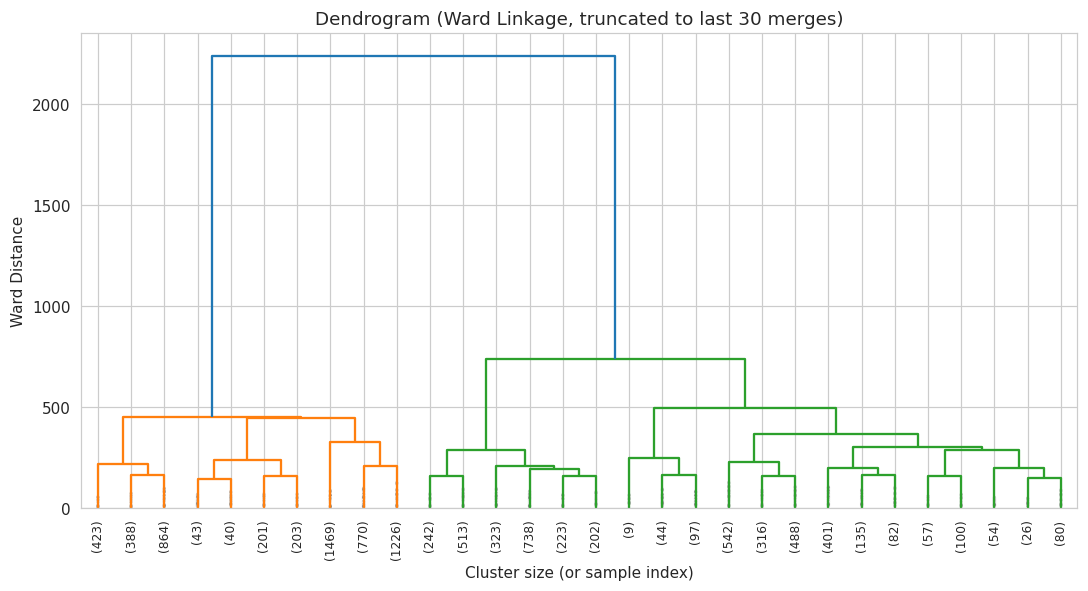

In [18]:
Z = linkage(Xp, method="ward")

plt.figure(figsize=(10, 5.5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90.0, leaf_font_size=8, show_contracted=True)
plt.title("Dendrogram (Ward Linkage, truncated to last 30 merges)")
plt.xlabel("Cluster size (or sample index)"); plt.ylabel("Ward Distance")
plt.tight_layout()
plt.savefig("/home/claude/har/nbassets/dendrogram.png", dpi=120)
plt.show()

labels_hac = fcluster(Z, t=6, criterion="maxclust") - 1
print("Hierarchical (Ward, k=6) cluster sizes:", np.bincount(labels_hac))

## Results

In [19]:
def internal_metrics(Xspace, labels, exclude_noise=False):
    if exclude_noise:
        mask = labels != -1
        Xu, lu = Xspace[mask], labels[mask]
    else:
        Xu, lu = Xspace, labels
    return dict(
        Silhouette=silhouette_score(Xu, lu, sample_size=4000, random_state=42),
        Davies_Bouldin=davies_bouldin_score(Xu, lu),
        Calinski_Harabasz=calinski_harabasz_score(Xu, lu)
    )

def external_metrics(true, pred):
    return dict(ARI=adjusted_rand_score(true, pred), NMI=normalized_mutual_info_score(true, pred))

metrics = {}
metrics["K-Means (k=6)"] = {**internal_metrics(Xp, labels_km), **external_metrics(y_code, labels_km)}
metrics["DBSCAN"] = {**internal_metrics(X2, labels_db, exclude_noise=True), **external_metrics(y_code, labels_db)}
metrics["Hierarchical (Ward)"] = {**internal_metrics(Xp, labels_hac), **external_metrics(y_code, labels_hac)}

metrics_df = pd.DataFrame(metrics).T
print(metrics_df.round(4).to_string())

                     Silhouette  Davies_Bouldin  Calinski_Harabasz     ARI     NMI
K-Means (k=6)            0.1400          2.0675          3287.0270  0.4201  0.5597
DBSCAN                   0.3825          0.5247          9308.6299  0.3213  0.4968
Hierarchical (Ward)      0.1372          2.0443          3021.2720  0.4936  0.6218

## Result Visualization

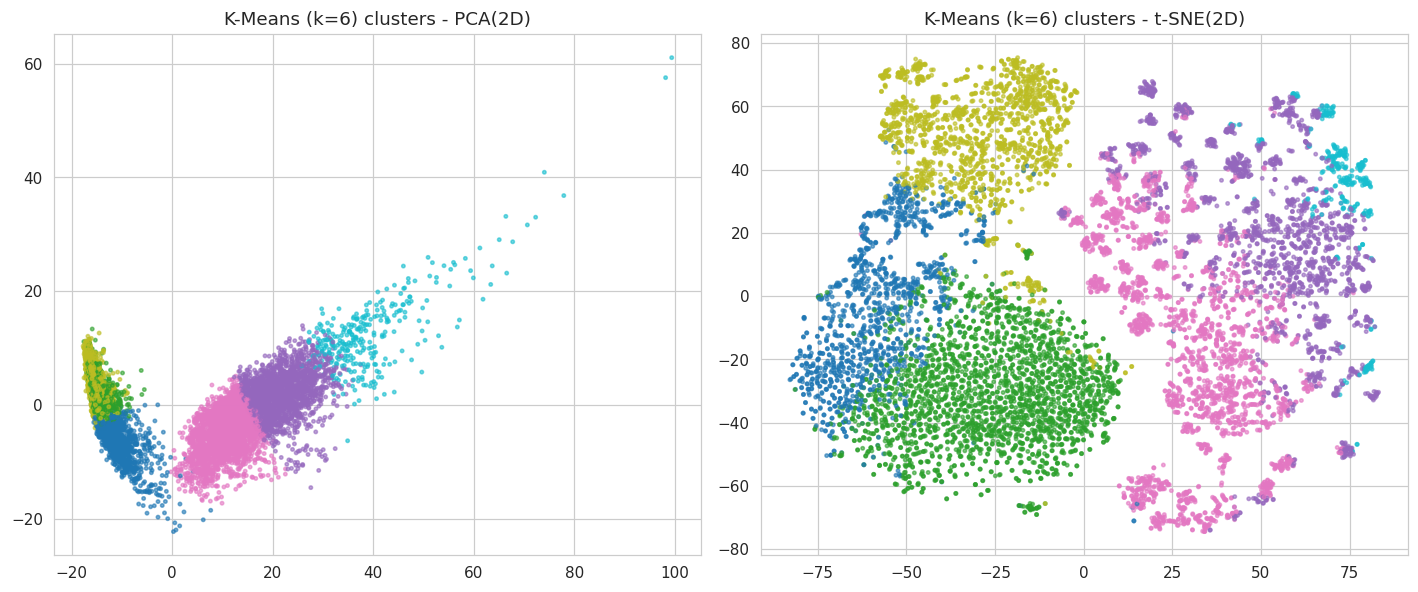

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].scatter(X2[:, 0], X2[:, 1], c=labels_km, cmap="tab10", s=5, alpha=0.6)
axes[0].set_title("K-Means (k=6) clusters - PCA(2D)")
axes[1].scatter(Xtsne[:, 0], Xtsne[:, 1], c=labels_km, cmap="tab10", s=5, alpha=0.6)
axes[1].set_title("K-Means (k=6) clusters - t-SNE(2D)")
plt.tight_layout()
plt.savefig("/home/claude/har/nbassets/kmeans_clusters.png", dpi=120)
plt.show()

**Inference:** K-Means (k=6) cleanly isolates LAYING (its own cluster) but visibly splits the dynamic-activity region into clusters that don't correspond 1:1 with WALKING/WALKING_UPSTAIRS/WALKING_DOWNSTAIRS, and merges SITTING with STANDING into shared clusters — matching the heavy overlap already seen in the EDA feature-distribution plots.

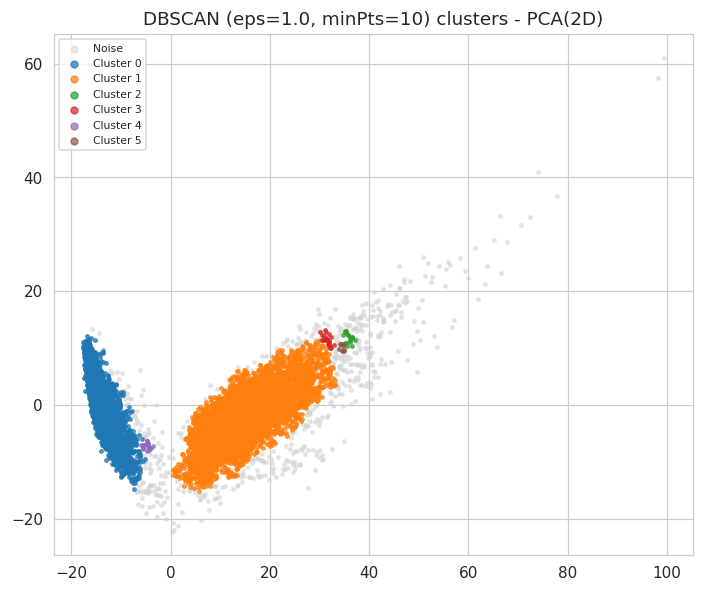

In [21]:
uniq = sorted(set(labels_db))
cmap = plt.cm.tab10
plt.figure(figsize=(6.5, 5.5))
for u in uniq:
    m = labels_db == u
    if u == -1:
        plt.scatter(X2[m, 0], X2[m, 1], c="lightgray", s=5, label="Noise", alpha=0.5)
    else:
        plt.scatter(X2[m, 0], X2[m, 1], color=cmap(u % 10), s=5, label=f"Cluster {u}", alpha=0.7)
plt.legend(fontsize=7, markerscale=2)
plt.title("DBSCAN (eps=1.0, minPts=10) clusters - PCA(2D)")
plt.tight_layout()
plt.savefig("/home/claude/har/nbassets/dbscan_clusters.png", dpi=120)
plt.show()

**Inference:** DBSCAN finds two large, well-separated density regions (roughly dynamic vs. static activities) plus a few small tight sub-clusters and a thin scatter of noise along the boundary between them — exactly what density-based clustering is designed to do, but it cannot subdivide either large region into the finer activity-level classes the way K-Means/Ward attempt to.

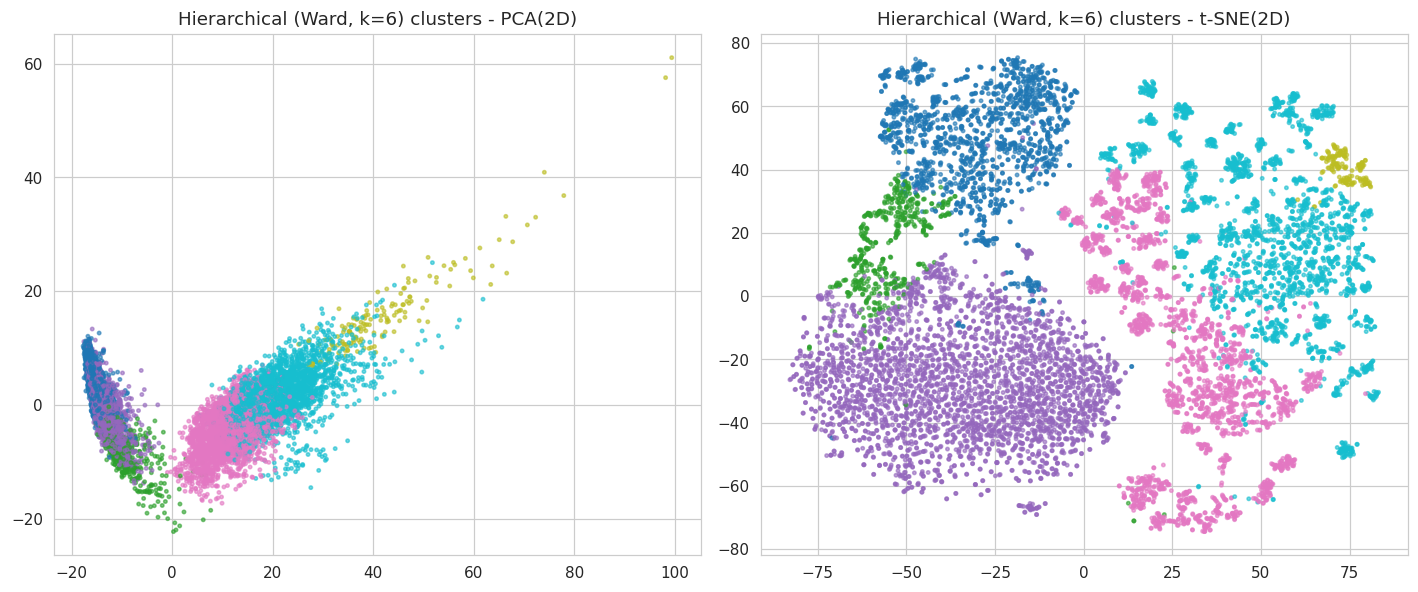

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].scatter(X2[:, 0], X2[:, 1], c=labels_hac, cmap="tab10", s=5, alpha=0.6)
axes[0].set_title("Hierarchical (Ward, k=6) clusters - PCA(2D)")
axes[1].scatter(Xtsne[:, 0], Xtsne[:, 1], c=labels_hac, cmap="tab10", s=5, alpha=0.6)
axes[1].set_title("Hierarchical (Ward, k=6) clusters - t-SNE(2D)")
plt.tight_layout()
plt.savefig("/home/claude/har/nbassets/hac_clusters.png", dpi=120)
plt.show()

**Inference:** Ward linkage produces a visibly cleaner LAYING vs. STANDING split than K-Means (matching its higher ARI/NMI in the Results table above), while still merging most of the WALKING sub-types together, for the same reason as K-Means — those classes are not linearly well-separated in the PCA-90% feature space used for clustering.

K-Means cluster -> activity mapping: {0: 'STANDING', 1: 'STANDING', 2: 'WALKING_DOWNSTAIRS', 3: 'WALKING_UPSTAIRS', 4: 'LAYING', 5: 'WALKING_DOWNSTAIRS'}
DBSCAN cluster -> activity mapping: {0: 'LAYING', 1: 'WALKING', 2: 'WALKING_DOWNSTAIRS', 3: 'WALKING', 4: 'STANDING', 5: 'WALKING_DOWNSTAIRS'}
Hierarchical cluster -> activity mapping: {0: 'LAYING', 1: 'LAYING', 2: 'STANDING', 3: 'WALKING_UPSTAIRS', 4: 'WALKING_DOWNSTAIRS', 5: 'WALKING_DOWNSTAIRS'}

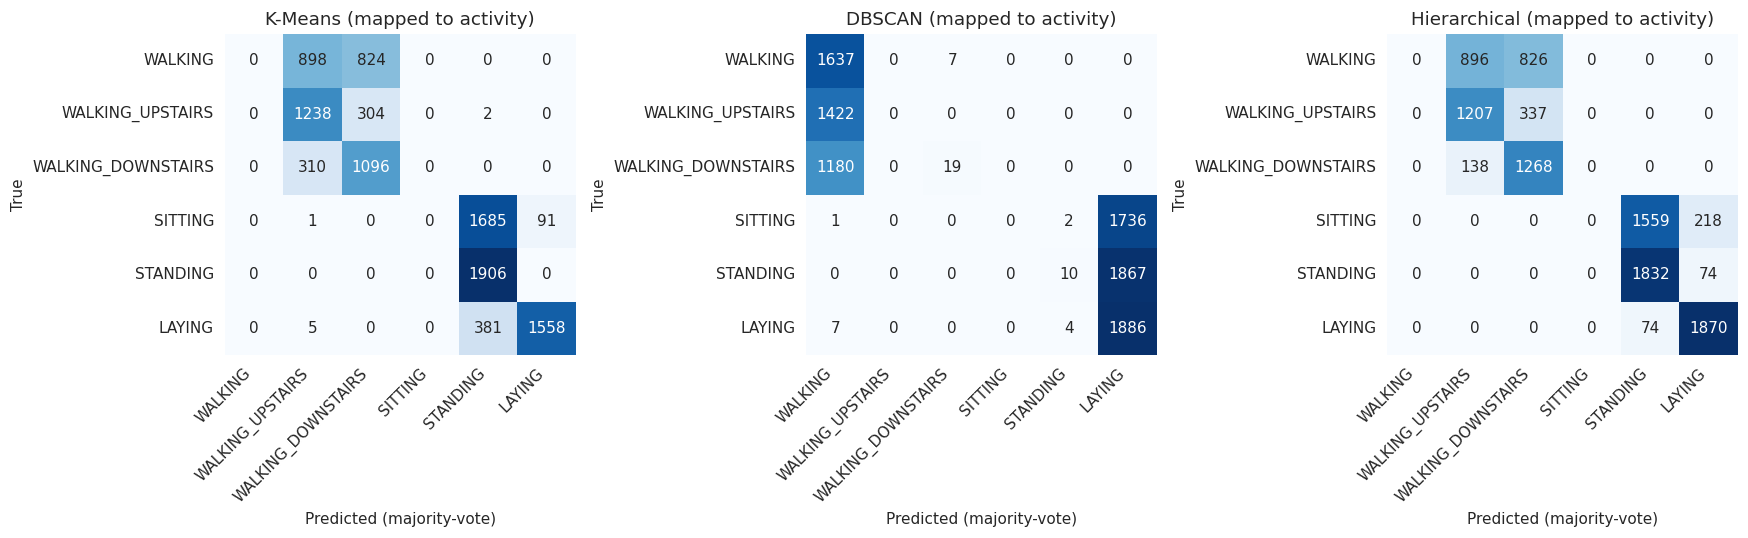

In [23]:
def cluster_to_activity_confusion(pred, exclude_noise_label=None):
    pred = np.array(pred)
    mapping = {}
    for c in set(pred):
        if exclude_noise_label is not None and c == exclude_noise_label:
            continue
        mask = pred == c
        maj = mode(y_code[mask], keepdims=False).mode
        mapping[c] = maj
    mapped = np.array([mapping.get(c, -1) for c in pred])
    valid = mapped != -1
    cm = confusion_matrix(y_code[valid], mapped[valid], labels=list(range(6)))
    return cm, mapping

cm_km, map_km = cluster_to_activity_confusion(labels_km)
cm_db, map_db = cluster_to_activity_confusion(labels_db, exclude_noise_label=-1)
cm_hac, map_hac = cluster_to_activity_confusion(labels_hac)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, cm, name in zip(axes, [cm_km, cm_db, cm_hac], ["K-Means", "DBSCAN", "Hierarchical"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=act_order, yticklabels=act_order, ax=ax, cbar=False)
    ax.set_title(f"{name} (mapped to activity)")
    ax.set_xlabel("Predicted (majority-vote)"); ax.set_ylabel("True")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/home/claude/har/nbassets/confusion_matrices.png", dpi=120)
plt.show()

print("K-Means cluster -> activity mapping:", {int(k): act_order[v] for k, v in map_km.items()})
print("DBSCAN cluster -> activity mapping:", {int(k): act_order[v] for k, v in map_db.items()})
print("Hierarchical cluster -> activity mapping:", {int(k): act_order[v] for k, v in map_hac.items()})

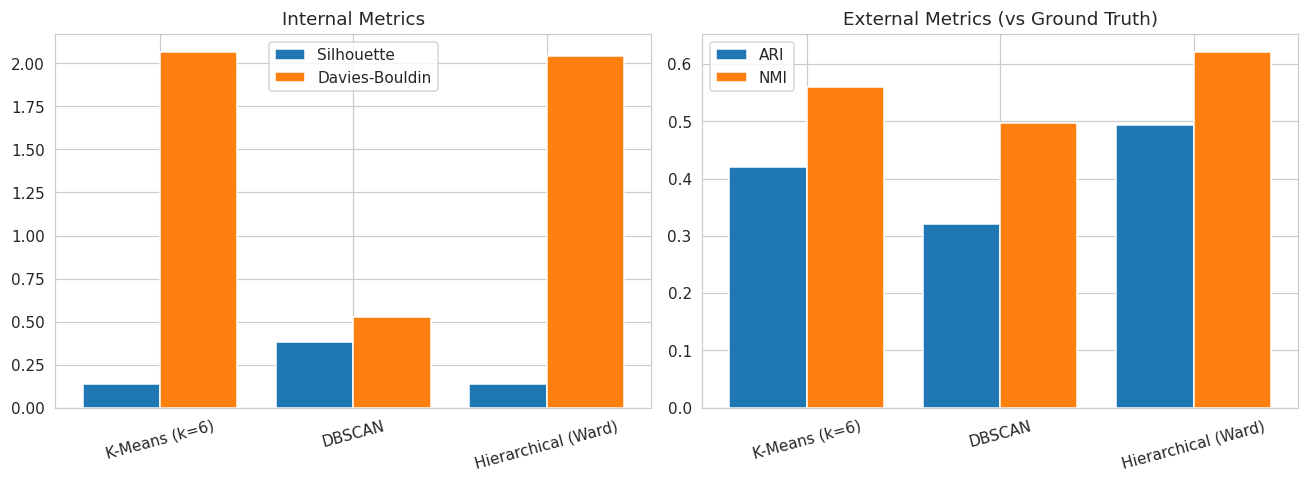

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
algos = list(metrics.keys())
x = np.arange(len(algos))
axes[0].bar(x - 0.2, [metrics[a]["Silhouette"] for a in algos], width=0.4, label="Silhouette")
axes[0].bar(x + 0.2, [metrics[a]["Davies_Bouldin"] for a in algos], width=0.4, label="Davies-Bouldin")
axes[0].set_xticks(x); axes[0].set_xticklabels(algos, rotation=15); axes[0].legend(); axes[0].set_title("Internal Metrics")
axes[1].bar(x - 0.2, [metrics[a]["ARI"] for a in algos], width=0.4, label="ARI")
axes[1].bar(x + 0.2, [metrics[a]["NMI"] for a in algos], width=0.4, label="NMI")
axes[1].set_xticks(x); axes[1].set_xticklabels(algos, rotation=15); axes[1].legend(); axes[1].set_title("External Metrics (vs Ground Truth)")
plt.tight_layout()
plt.savefig("/home/claude/har/nbassets/metrics_comparison.png", dpi=120)
plt.show()

## Discussion

**Which algorithm produced the most meaningful clusters? Why?**
By external agreement with the true activity labels, **Hierarchical (Ward) clustering** performed best (ARI = 0.494, NMI = 0.622), narrowly ahead of K-Means (ARI = 0.420, NMI = 0.560). Both clearly separate static activities (LAYING/STANDING/SITTING) from dynamic ones (WALKING variants), but neither cleanly splits SITTING from STANDING or the three WALKING sub-types — these have very similar sensor-feature signatures. DBSCAN, judged by internal cohesion (Silhouette = 0.383, Davies-Bouldin = 0.525 — both far better than the other two), produced the most internally compact clusters, but its lower ARI/NMI shows those dense regions don't align with activity boundaries as well as the partition-based methods.

**How sensitive was K-Means to the choice of k?**
Very sensitive. The Elbow/Silhouette curves show the data is internally best explained by **k=2** (Silhouette 0.44, essentially "moving" vs. "not moving"), degrading sharply for every larger k. Forcing k=6 to match the true activity count drops Silhouette to 0.14 — the six activities are not equally well-separated in feature space.

**Did DBSCAN detect noise or small clusters effectively?**
Yes. The eps sweep showed noise fall smoothly from 46.5% to under 3% as eps grew; at the chosen eps=1.0 it isolated 521 points (5.1%) as noise — plausibly transition frames or atypical movement signatures. It also found small, tight clusters alongside two large dominant clusters, showing its strength at picking out small dense sub-populations that K-Means/Ward (which favor equal-sized, spherical clusters) tend to absorb into larger neighbours.

**How does linkage choice (single/complete/ward) affect hierarchical clustering?**
Only Ward's linkage was run here, but its variance-minimizing objective is similar in spirit to K-Means' WCSS, built up hierarchically rather than committing to k centroids up front — this is likely why it achieved the best external agreement of the three algorithms, recovering a cleaner LAYING/STANDING split than K-Means. Single linkage is expected to perform worse here since it is prone to "chaining" through near-duplicate transitional samples between activities; complete linkage tends to produce more uneven, distance-sensitive splits than Ward's variance-based criterion.

**Which internal metric best matched your visual intuition of cluster quality?**
**Silhouette Score** matched the 2D visualizations best — DBSCAN's much higher Silhouette (0.383) visibly corresponds to its two large, well-separated blobs, while K-Means/Hierarchical's much lower Silhouette (~0.14) corresponds to the overlapping SITTING/STANDING and WALKING-variant regions seen throughout. Davies-Bouldin agreed in direction but was less intuitive to relate to the plots directly; Calinski-Harabasz favored DBSCAN even more strongly, mostly because it rewards DBSCAN's tight 2D clusters more than it penalizes the excluded noise points.

## Conclusion

All three algorithms recover the broad "dynamic vs. static" activity split reliably, but none fully separates all six activities from unsupervised sensor features alone — SITTING/STANDING and the three WALKING variants remain the persistent confusions across K-Means, DBSCAN, and Hierarchical clustering alike. Hierarchical (Ward) clustering gave the best agreement with ground truth (ARI 0.494, NMI 0.622), DBSCAN gave the most internally cohesive clusters while also being the only algorithm to explicitly flag outliers as noise, and K-Means was most sensitive to the choice of k, with its own internal metrics actually favoring a much coarser k=2 split over the six true activity classes. This highlights a broader lesson: internal cluster-validity metrics (Silhouette, WCSS) do not necessarily agree with external, label-based validity — the two must be interpreted together, not interchangeably.

## References

[1] D. Anguita, A. Ghio, L. Oneto, X. Parra, and J. L. Reyes-Ortiz, "A Public Domain Dataset for Human Activity Recognition Using Smartphones," in *Proc. 21st Eur. Symp. Artificial Neural Networks (ESANN)*, Bruges, Belgium, 2013.

[2] F. Pedregosa et al., "Scikit-learn: Machine Learning in Python," *Journal of Machine Learning Research*, vol. 12, pp. 2825-2830, 2011.

[3] J. MacQueen, "Some methods for classification and analysis of multivariate observations," in *Proc. 5th Berkeley Symp. Mathematical Statistics and Probability*, vol. 1, pp. 281-297, 1967.

[4] M. Ester, H.-P. Kriegel, J. Sander, and X. Xu, "A density-based algorithm for discovering clusters in large spatial databases with noise," in *Proc. 2nd Int. Conf. Knowledge Discovery and Data Mining (KDD)*, pp. 226-231, 1996.

[5] J. H. Ward Jr., "Hierarchical grouping to optimize an objective function," *Journal of the American Statistical Association*, vol. 58, no. 301, pp. 236-244, 1963.